# The Algebra Sketchpad

**Programming Design Principles (5N2927) -- Skills Demo 2b, 15%**
**Maths for IT (5N18396) -- Assignment 1b, 18%**

Dundrum College of Further Education | Dublin and Dun Laoghaire ETB

---

In this skills demo you will build a small algebra engine and then use it to draw pictures. Polynomials are not just abstract symbols on a page -- they are curves, and curves are shapes. By the end you will use polynomial evaluation to render Bezier curves and draw letters on screen.

## Assessment Criteria

| Criterion | PDP Marks | MIT Marks |
|---|---|---|
| Pseudocode and algorithm design | 4 | -- |
| Working code with functions and testing | 8 | -- |
| Correct use of number domains, polynomials, equations | -- | 8 |
| Accurate calculations with proper notation | -- | 5 |
| Coherent format and logical progression | -- | 5 |

---

## Provided Tools

Run this cell to load the drawing helpers.

In [1]:
# === PROVIDED: Drawing helpers ===
import math
import matplotlib.pyplot as plt

def plot_polynomial(coeffs, x_min=-5, x_max=5, label=None, colour='#4e79a7'):
    """Plot a polynomial given as a list of coefficients [c0, c1, c2, ...]."""
    xs = [x_min + i * (x_max - x_min) / 200 for i in range(201)]
    ys = []
    for x in xs:
        y = 0
        for i, c in enumerate(coeffs):
            y += c * x**i
        ys.append(y)
    plt.plot(xs, ys, linewidth=2, label=label, color=colour)

def draw_bezier(control_points, num_steps=100, colour='#4e79a7', linewidth=2):
    """
    Draw a quadratic Bezier curve from 3 control points.
    Each control point is (x, y).
    """
    p0, p1, p2 = control_points
    xs, ys = [], []
    for i in range(num_steps + 1):
        t = i / num_steps
        # Quadratic Bezier formula:
        # B(t) = (1-t)^2 * P0 + 2(1-t)t * P1 + t^2 * P2
        x = (1-t)**2 * p0[0] + 2*(1-t)*t * p1[0] + t**2 * p2[0]
        y = (1-t)**2 * p0[1] + 2*(1-t)*t * p1[1] + t**2 * p2[1]
        xs.append(x)
        ys.append(y)
    plt.plot(xs, ys, linewidth=linewidth, color=colour)

def draw_letter_canvas(width=10, height=12):
    """Set up a canvas for drawing letters."""
    plt.figure(figsize=(5, 6))
    plt.xlim(0, width)
    plt.ylim(0, height)
    plt.gca().set_aspect('equal')
    plt.grid(True, alpha=0.2)

print("Drawing helpers loaded.")

Drawing helpers loaded.


---

### Exercise 1: Number Families

Write a function that classifies a number into the domains it belongs to: Natural (N), Integer (Z), Rational (Q), Real (R).

In [2]:
# Pseudocode:
# If n is a whole number (an int, or a float with no fractional part):
#     it belongs to Z, and to N as well if it is not negative
#     every whole number also belongs to Q and R
# If n is a float with a fractional part:
#     if it matches a well-known irrational constant (like pi), it only belongs to R
#     otherwise treat it as a rational with a finite decimal expansion (Q and R)


In [3]:
import math

def classify_number(n):
    """
    Return a list of the domains the number belongs to.
    E.g., classify_number(7) -> ["N", "Z", "Q", "R"]
          classify_number(-3.5) -> ["Q", "R"]
    """
    domains = []

    if isinstance(n, int):
        if n >= 0:
            domains.append("N")
        domains.extend(["Z", "Q", "R"])
        return domains

    if isinstance(n, float):
        if n.is_integer():
            if n >= 0:
                domains.append("N")
            domains.extend(["Z", "Q", "R"])
            return domains

        known_irrationals = [math.pi, math.e, math.sqrt(2), math.sqrt(3), math.sqrt(5)]
        for irrational in known_irrationals:
            if abs(n - irrational) < 1e-4:
                domains.append("R")
                return domains

        domains.extend(["Q", "R"])
        return domains

    return domains


In [4]:
# Test with: 7, -3, 0, 0.5, -2.5, 3.14159
for n in [7, -3, 0, 0.5, -2.5, 3.14159]:
    print(n, classify_number(n))


7 ['N', 'Z', 'Q', 'R']
-3 ['Z', 'Q', 'R']
0 ['N', 'Z', 'Q', 'R']
0.5 ['Q', 'R']
-2.5 ['Q', 'R']
3.14159 ['R']


---

### Exercise 2: Polynomial Toolkit

We represent a polynomial as a list of coefficients where index $i$ holds the coefficient of $x^i$. So $3x^2 + 5x - 2$ becomes `[-2, 5, 3]`.

Write three functions: evaluate, add, and multiply.

In [5]:
# Pseudocode:
# evaluate_poly(coeffs, x): add up coeff * x^power for every power present
# add_poly(a, b): add matching-power coefficients together, padding the
#     shorter list with zeros
# multiply_poly(a, b): every pair of coefficients a[i], b[j] contributes
#     a[i] * b[j] to position i + j in the result


In [6]:
def evaluate_poly(coeffs, x):
    """Evaluate the polynomial at a given value of x."""
    total = 0
    for power_index, coeff in enumerate(coeffs):
        total += coeff * x ** power_index
    return total

def add_poly(a, b):
    """Add two polynomials. Return a new coefficient list."""
    length = max(len(a), len(b))
    result = []
    for i in range(length):
        coeff_a = a[i] if i < len(a) else 0
        coeff_b = b[i] if i < len(b) else 0
        result.append(coeff_a + coeff_b)
    return result

def multiply_poly(a, b):
    """Multiply two polynomials. Return a new coefficient list."""
    result = [0] * (len(a) + len(b) - 1)
    for i, coeff_a in enumerate(a):
        for j, coeff_b in enumerate(b):
            result[i + j] += coeff_a * coeff_b
    return result


In [7]:
# Tests
# evaluate_poly([-2, 5, 3], 0) should be -2
# evaluate_poly([-2, 5, 3], 1) should be 6
# evaluate_poly([-2, 5, 3], 4) should be 66
# add_poly([-2, 5, 3], [7, -3, 1]) should be [5, 2, 4]
# multiply_poly([3, 2], [4, 1]) should be [12, 11, 2]
print(evaluate_poly([-2, 5, 3], 0))
print(evaluate_poly([-2, 5, 3], 1))
print(evaluate_poly([-2, 5, 3], 4))
print(add_poly([-2, 5, 3], [7, -3, 1]))
print(multiply_poly([3, 2], [4, 1]))


-2
6
66
[5, 2, 4]
[12, 11, 2]


**Visualise your polynomials:**

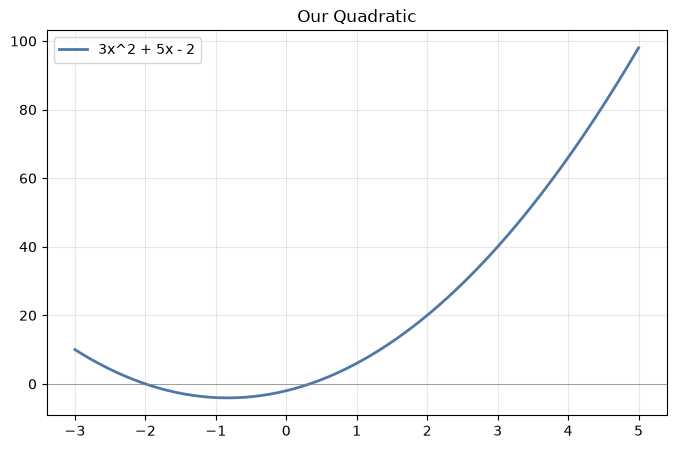

In [8]:
# Plot a polynomial and verify it looks right
plt.figure(figsize=(8, 5))
plot_polynomial([-2, 5, 3], x_min=-3, x_max=5, label="3x^2 + 5x - 2")
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.legend()
plt.title("Our Quadratic")
plt.grid(True, alpha=0.3)
plt.show()

---

### Exercise 3: Solving Equations

Write a function that solves quadratic equations using the quadratic formula.

$$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

Handle all three cases: two roots (discriminant > 0), one root (discriminant = 0), no real roots (discriminant < 0).

In [9]:
# Pseudocode:
# Work out the discriminant b^2 - 4ac
# If it's positive: two roots, using +/- sqrt(discriminant) in the formula
# If it's zero: one repeated root, -b / (2a)
# If it's negative: no real roots, return an empty tuple


In [10]:
def solve_quadratic(coeffs):
    """
    Solve ax^2 + bx + c = 0 given coeffs = [c, b, a].
    Returns a tuple of roots (may be empty, 1 element, or 2 elements).
    """
    c, b, a = coeffs
    discriminant = b ** 2 - 4 * a * c
    if discriminant > 0:
        root1 = (-b + discriminant ** 0.5) / (2 * a)
        root2 = (-b - discriminant ** 0.5) / (2 * a)
        return (root1, root2)
    elif discriminant == 0:
        return (-b / (2 * a),)
    else:
        return ()


In [11]:
# Tests -- verify roots by plugging them back in
# solve_quadratic([3, -4, 1]) -> roots of x^2 - 4x + 3 = 0 (should be 1 and 3)
# solve_quadratic([1, -2, 1]) -> root of x^2 - 2x + 1 = 0 (should be 1, repeated)
# solve_quadratic([5, 0, 1]) -> x^2 + 5 = 0 (no real roots)
print(solve_quadratic([3, -4, 1]))
print(solve_quadratic([1, -2, 1]))
print(solve_quadratic([5, 0, 1]))

# Verification: evaluate_poly at each root should give (close to) 0
for root in solve_quadratic([3, -4, 1]):
    print(f"evaluate_poly at {root}:", evaluate_poly([3, -4, 1], root))


(3.0, 1.0)
(1.0,)
()
evaluate_poly at 3.0: 0.0
evaluate_poly at 1.0: 0.0


**Where do two polynomials meet?** Two polynomials $p(x)$ and $q(x)$ intersect where $p(x) - q(x) = 0$. Use `add_poly` (with negation) and `solve_quadratic` to find where $x^2$ and $2x + 3$ intersect. Then plot both curves to confirm visually.

Intersection x-values: (3.0, -1.0)


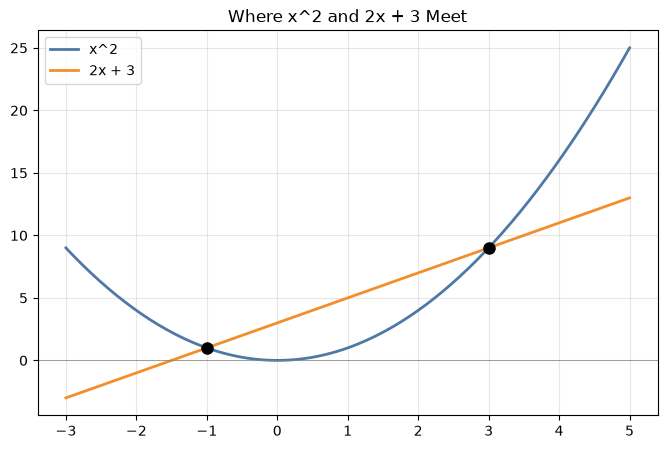

In [12]:
# Find and plot intersection points
# x^2 = 2x + 3  =>  x^2 - 2x - 3 = 0
diff_coeffs = add_poly([0, 0, 1], [-3, -2, 0])
roots = solve_quadratic(diff_coeffs)
print("Intersection x-values:", roots)

plt.figure(figsize=(8, 5))
plot_polynomial([0, 0, 1], x_min=-3, x_max=5, label="x^2")
plot_polynomial([3, 2], x_min=-3, x_max=5, label="2x + 3", colour="#f28e2b")
for root in roots:
    y = evaluate_poly([0, 0, 1], root)
    plt.plot(root, y, 'ko', markersize=8)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.legend()
plt.title("Where x^2 and 2x + 3 Meet")
plt.grid(True, alpha=0.3)
plt.show()


---

### Exercise 4: Drawing with Bezier Curves

A quadratic Bezier curve is defined by three control points and uses the formula:

$$B(t) = (1-t)^2 P_0 + 2(1-t)t P_1 + t^2 P_2, \quad t \in [0, 1]$$

Notice: this is a polynomial in $t$. The `draw_bezier` function is provided for you. Your job is to choose control points that draw a letter.

Here is an example that draws a rough letter "C":

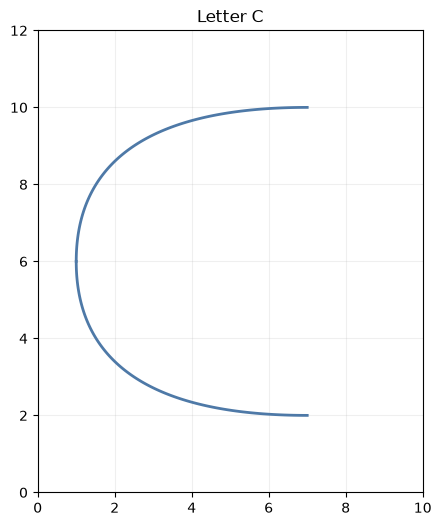

In [13]:
draw_letter_canvas()

# Letter C: three Bezier curves
draw_bezier([(7, 10), (1, 10), (1, 6)])   # top curve
draw_bezier([(1, 6), (1, 2), (7, 2)])     # bottom curve

plt.title("Letter C")
plt.show()

**Your task:** Draw at least two different letters using Bezier curves. Experiment with the control points to get shapes you are happy with. Each letter might need 2-4 Bezier curves.

Some letters that work well: L (just straight lines -- control points in a line), S (two curves), U, J, O (four curves making an oval).

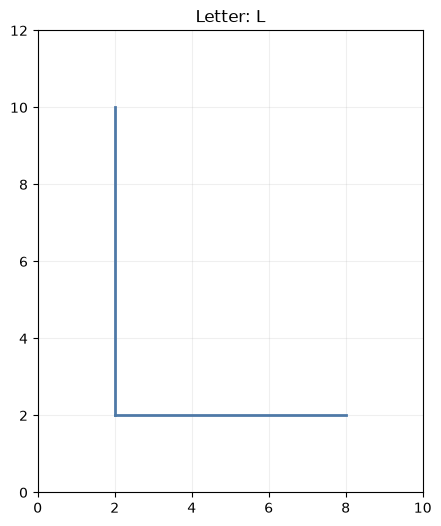

In [14]:
# Your first letter
draw_letter_canvas()

# Letter L: two straight strokes (a Bezier with a control point sitting on
# the straight line between the endpoints just draws a straight line)
draw_bezier([(2, 10), (2, 6), (2, 2)])   # vertical stroke
draw_bezier([(2, 2), (5, 2), (8, 2)])    # horizontal stroke

plt.title("Letter: L")
plt.show()


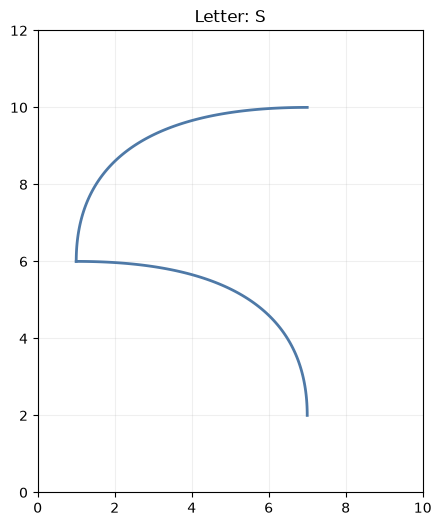

In [15]:
# Your second letter
draw_letter_canvas()

# Letter S: two curves swinging in opposite directions
draw_bezier([(7, 10), (1, 10), (1, 6)])   # top curve, opening downward
draw_bezier([(1, 6), (7, 6), (7, 2)])     # bottom curve, opening upward

plt.title("Letter: S")
plt.show()


**Connection to polynomials:** The Bezier formula expands to a polynomial in $t$. For a quadratic Bezier with control points $P_0 = (0, 0)$, $P_1 = (1, 2)$, $P_2 = (3, 0)$:

$x(t) = (1-t)^2 \cdot 0 + 2(1-t)t \cdot 1 + t^2 \cdot 3 = 2t - 2t^2 + 3t^2 = 2t + t^2$

So the x-coordinate is the polynomial $t^2 + 2t$, which in our list convention is `[0, 2, 1]`.

Expand the y-coordinate polynomial for those same control points and verify using `evaluate_poly`:

In [16]:
# Your expansion of y(t) and verification
# y(t) = (1-t)^2 * 0 + 2(1-t)t * 2 + t^2 * 0 = 4t(1-t) = 4t - 4t^2
# In our list convention: [0, 4, -4]

y_coeffs = [0, 4, -4]
for t in [0, 0.25, 0.5, 0.75, 1]:
    expected = 4 * t - 4 * t ** 2
    computed = evaluate_poly(y_coeffs, t)
    print(f"t={t}: expected={expected}, evaluate_poly={computed}")


t=0: expected=0, evaluate_poly=0
t=0.25: expected=0.75, evaluate_poly=0.75
t=0.5: expected=1.0, evaluate_poly=1.0
t=0.75: expected=0.75, evaluate_poly=0.75
t=1: expected=0, evaluate_poly=0


---

### Exercise 5: Sets

Write functions for the core set operations. We represent sets as sorted lists with no duplicates.

In [17]:
# Pseudocode:
#
#


In [18]:
def make_set(items):
    """Create a sorted list with no duplicates."""
    result = []
    for item in sorted(items):
        if not result or result[-1] != item:
            result.append(item)
    return result

def union(a, b):
    """Elements in a or b (or both)."""
    result = []
    i = j = 0
    while i < len(a) and j < len(b):
        if a[i] < b[j]:
            result.append(a[i])
            i += 1
        elif a[i] > b[j]:
            result.append(b[j])
            j += 1
        else:
            result.append(a[i])
            i += 1
            j += 1
    result.extend(a[i:])
    result.extend(b[j:])
    return result

def intersection(a, b):
    """Elements in both a and b."""
    result = []
    i = j = 0
    while i < len(a) and j < len(b):
        if a[i] < b[j]:
            i += 1
        elif a[i] > b[j]:
            j += 1
        else:
            result.append(a[i])
            i += 1
            j += 1
    return result

def difference(a, b):
    """Elements in a but not in b."""
    return [item for item in a if item not in b]


In [19]:
# Tests
a = make_set([3, 1, 4, 1, 5, 9, 2, 6])
b = make_set([5, 7, 2, 8, 1])
print("a:", a)
print("b:", b)
print("union:", union(a, b))
print("intersection:", intersection(a, b))
print("difference a-b:", difference(a, b))
print("difference b-a:", difference(b, a))

# Verify: |a union b| should equal |a| + |b| - |a intersect b|
print(len(union(a, b)) == len(a) + len(b) - len(intersection(a, b)))


a: [1, 2, 3, 4, 5, 6, 9]
b: [1, 2, 5, 7, 8]
union: [1, 2, 3, 4, 5, 6, 7, 8, 9]
intersection: [1, 2, 5]
difference a-b: [3, 4, 6, 9]
difference b-a: [7, 8]
True


**Apply to equations:** Find the roots of several quadratics and use set operations to find which roots are shared:

In [20]:
# Roots of x^2 - 4x + 3 = 0 (roots: 1, 3)
# Roots of x^2 - 3x + 2 = 0 (roots: 1, 2)
# Roots of x^2 - 5x + 6 = 0 (roots: 2, 3)
set1 = make_set(list(solve_quadratic([3, -4, 1])))
set2 = make_set(list(solve_quadratic([2, -3, 1])))
set3 = make_set(list(solve_quadratic([6, -5, 1])))

# Find: which root appears in all three? Use intersection.
common = intersection(intersection(set1, set2), set3)
print("Root common to all three:", common)

# Find: the set of all roots across all three. Use union.
all_roots = union(union(set1, set2), set3)
print("All roots across the three equations:", all_roots)


Root common to all three: []
All roots across the three equations: [1.0, 2.0, 3.0]


---

### Reflection

Write a few sentences: what was the most satisfying part of this skills demo? Did drawing with Bezier curves change how you think about polynomials?

